<a href="https://colab.research.google.com/github/B-lr/yoloV8/blob/main/yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 #Loading 2017 cocodataset
 !wget http://images.cocodataset.org/zips/val2017.zip
 !wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O coco_ann2017.zip

--2026-05-01 05:36:01--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.216.217.201, 3.5.30.165, 16.15.207.224, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.216.217.201|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  30.6MB/s    in 10s     

2026-05-01 05:36:11 (75.8 MB/s) - ‘val2017.zip’ saved [815585330/815585330]

--2026-05-01 05:36:12--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.252.238, 54.231.228.233, 52.216.221.65, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.252.238|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘coco_ann2017.zip’

coco_ann2017.zip    100%[====

In [2]:
#extracting coco datasets to folder
from zipfile import ZipFile, BadZipFile
import os
def extract_zip_file(extract_path):
    try:
        with ZipFile(extract_path+".zip") as zfile:
            zfile.extractall(extract_path)
        # remove zipfile
        zfileTOremove=f"{extract_path}"+".zip"
        if os.path.isfile(zfileTOremove):
            os.remove(zfileTOremove)
        else:
            print("Error: %s file not found" % zfileTOremove)
    except BadZipFile as e:
        print("Error:", e)

extract_val_path = "./val2017"
extract_ann_path="./coco_ann2017"

extract_zip_file(extract_val_path)
extract_zip_file(extract_ann_path)

In [4]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.2 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import os

# Load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")  # nano model (fast)

# Path to COCO val images
image_dir = "/content/val2017/val2017/000000000785.jpg"

# Run detection on all images
results = model.predict(
    source=image_dir,
    imgsz=640,
    conf=0.25,
    save=True,        # saves output images
    save_txt=False,   # set True if you want labels
    device="cpu"      # or "0" for GPU
)

print("Detection completed!")


image 1/1 /content/val2017/val2017/000000000785.jpg: 448x640 1 person, 1 skis, 177.6ms
Speed: 2.5ms preprocess, 177.6ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-3
Detection completed!



image 1/1 /content/val2017/val2017/000000000872.jpg: 640x640 2 persons, 427.6ms
Speed: 25.6ms preprocess, 427.6ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)


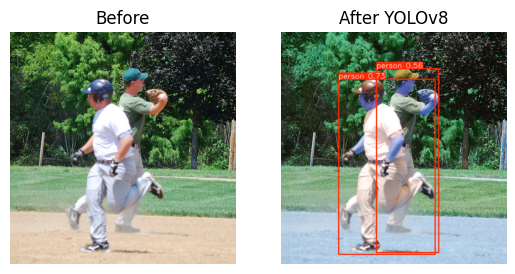

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

img_path = "/content/val2017/val2017/000000000872.jpg"

# Show original
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Before")
plt.axis("off")

# Run YOLO
model = YOLO("yolov8n.pt")
result = model(img_path)[0]

# Show predicted image
annotated = result.plot()

plt.subplot(1,2,2)
plt.imshow(annotated)
plt.title("After YOLOv8")
plt.axis("off")

plt.show()